AnnData object with n_obs × n_vars = 3624 × 27984


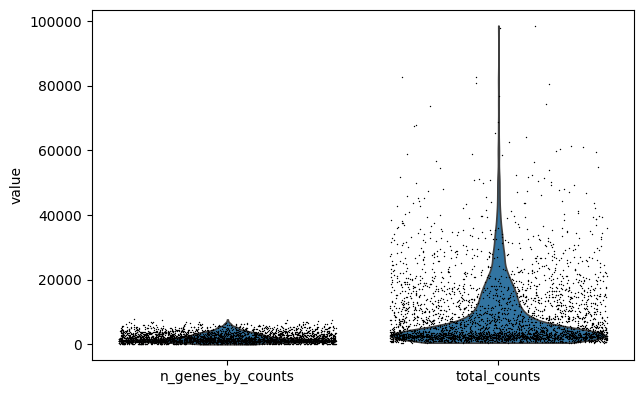

AnnData object with n_obs × n_vars = 3449 × 17640
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'


In [72]:
# ============================================================
# 1. Import Required Libraries
# ============================================================

# scanpy:
# Main framework used for single-cell RNA-seq analysis.
# Provides tools for preprocessing, quality control,
# dimensionality reduction, graph construction, and visualisation.

import scanpy as sc

# pandas:
# Used for reading and handling tabular files such as
# gene lists and barcode metadata.

import pandas as pd

# mmread:
# Used to load Matrix Market (.mtx) sparse matrix files,
# which store the raw gene expression counts.

from scipy.io import mmread

# ============================================================
# 2. Load Raw Gene Expression Matrix
# ============================================================

# The matrix file contains raw gene expression counts.
# Rows originally represent genes and columns represent cells.
# The matrix is transposed (.T) so that:
#
# rows   = cells
# columns = genes
#
# which is the format expected by Scanpy.

matrix = mmread(
    "../data/raw/GSE203115/sample_2/matrix.mtx.gz"
).T

# Convert matrix to CSR sparse format.
# This format is more efficient for filtering,
# indexing, and preprocessing operations.

matrix = matrix.tocsr()

# ============================================================
# 3. Load Gene Names
# ============================================================

# The features.tsv file contains the gene identifiers
# corresponding to each column in the expression matrix.

genes = pd.read_csv(
    "../data/raw/GSE203115/sample_2/features.tsv.gz",
    header=None
)

# ============================================================
# 4. Load Cell Barcodes
# ============================================================

# The barcodes.tsv file contains unique identifiers
# for each individual cell in the dataset.

barcodes = pd.read_csv(
    "../data/raw/GSE203115/sample_2/barcodes.tsv.gz",
    header=None
)

# ============================================================
# 5. Create AnnData Object
# ============================================================

# AnnData is the standard data structure used in Scanpy.
# It stores:
#
# - gene expression matrix
# - cell metadata
# - gene metadata
# - embeddings
# - graphs
# - preprocessing outputs
#
# in a single unified object.

adata = sc.AnnData(matrix)

# ============================================================
# 6. Assign Gene and Cell Names
# ============================================================

# Assign gene names to columns (variables/features).

adata.var_names = genes[0].values

# Assign cell barcodes to rows (observations/cells).

adata.obs_names = barcodes[0].values

# Print dataset dimensions:
# n_obs  = number of cells
# n_vars = number of genes

print(adata)

# ============================================================
# 7. Calculate Quality Control (QC) Metrics
# ============================================================

# QC metrics help evaluate the quality of each cell.
#
# Examples include:
# - number of genes detected per cell
# - total sequencing counts per cell
# - expression distribution statistics
#
# These metrics are stored in:
# adata.obs

sc.pp.calculate_qc_metrics(
    adata,
    inplace=True
)

# View the first few rows of cell metadata
# containing QC statistics.

adata.obs.head()

# ============================================================
# 8. Visualise Quality Control Distributions
# ============================================================

# Violin plots are used to visualise:
#
# - n_genes_by_counts:
#   number of genes detected in each cell
#
# - total_counts:
#   total sequencing reads/counts per cell
#
# This helps identify:
# - low-quality cells
# - sequencing outliers
# - abnormal cells

sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts'],
    jitter=0.4
)


# ============================================================
# 9. Filter Low-Quality Cells and Genes
# ============================================================

# Remove cells expressing fewer than 200 genes.
# These are often:
# - dead cells
# - empty droplets
# - poor-quality captures

sc.pp.filter_cells(
    adata,
    min_genes=200
)

# Remove genes expressed in fewer than 3 cells.
# These genes are usually uninformative or noisy.

sc.pp.filter_genes(
    adata,
    min_cells=3
)

# Print updated dataset dimensions after filtering.

print(adata)

In [73]:
# ============================================================
# 10. Normalisation of Gene Expression Data
# ============================================================

# Different cells can contain different total sequencing counts
# due to variations in sequencing depth and RNA capture efficiency.
#
# For example:
# - one cell may contain 50,000 total reads
# - another cell may contain 5,000 total reads
#
# This does not necessarily reflect true biological differences.
#
# Normalisation rescales each cell so that all cells have
# approximately the same total expression level, making them
# directly comparable for downstream analysis.

sc.pp.normalize_total(
    adata,
    target_sum=1e4
)

# target_sum = 1e4 means each cell is scaled so that
# the total counts across all genes sum to 10,000.


# ============================================================
# 11. Log Transformation
# ============================================================

# Gene expression values are highly skewed, where a small number
# of genes may have extremely large expression values.
#
# Log transformation compresses large values and stabilises
# variance across the dataset, improving the performance of:
#
# - dimensionality reduction
# - graph construction
# - clustering
# - machine learning models
#
# log1p(x) computes:
#
# log(x + 1)
#
# The +1 prevents issues with zero values.

sc.pp.log1p(adata)


# ============================================================
# 12. Inspect Normalised Expression Matrix
# ============================================================

# adata.X stores the main gene expression matrix.
#
# After normalisation and log transformation,
# this matrix now contains processed expression values
# instead of raw sequencing counts.

adata.X[:5]

# The matrix is stored in sparse format because
# single-cell datasets contain a large number of zero values.
#
# Sparse matrices improve memory efficiency by storing
# only non-zero entries.


# ============================================================
# 13. Convert Sparse Matrix to Dense Array
# ============================================================

# Convert the first 5 cells into a dense NumPy array
# to directly inspect the numerical expression values.

adata.X[:5].toarray()

# These values now represent:
# - normalised expression levels
# - after sequencing-depth correction
# - after log transformation
#
# This processed matrix will later be used for:
# - highly variable gene selection
# - PCA
# - graph construction
# - graph neural network learning

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5, 17640), dtype=float32)

In [74]:
# ============================================================
# 14. Highly Variable Gene (HVG) Selection
# ============================================================

# Single-cell datasets contain thousands of genes,
# many of which contribute little useful biological information.
#
# Highly variable genes (HVGs) are genes whose expression
# varies significantly across cells.
#
# These genes are more informative for identifying:
# - cell states
# - cell populations
# - biological differences
#
# Selecting HVGs reduces noise and computational complexity,
# while preserving the most important biological signals.

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000
)

# Keep only the highly variable genes.

adata = adata[:, adata.var.highly_variable]

# Print updated dataset dimensions.

print(adata)

View of AnnData object with n_obs × n_vars = 3449 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


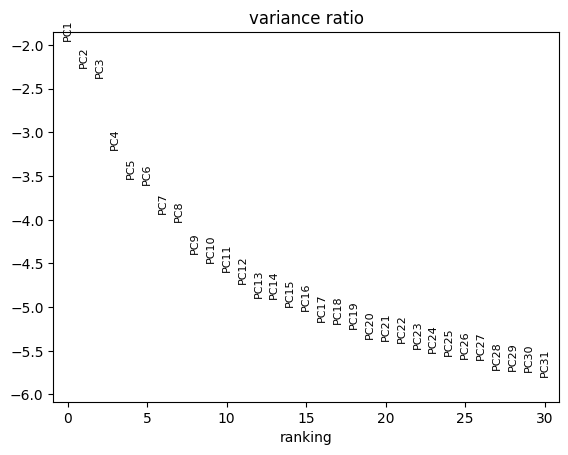

In [75]:
# ============================================================
# 15. Principal Component Analysis (PCA)
# ============================================================

# Even after highly variable gene selection,
# the dataset still contains thousands of features.
#
# PCA reduces the dimensionality of the dataset by
# transforming the original gene expression space into
# a smaller number of principal components.
#
# These components capture the major sources of
# biological variation across cells.
#
# Dimensionality reduction improves:
# - computational efficiency
# - clustering
# - graph construction
# - downstream machine learning performance

sc.tl.pca(adata)

# Visualise how much variance is explained
# by each principal component.

sc.pl.pca_variance_ratio(
    adata,
    log=True
)

In [76]:
# ============================================================
# 16. Cell-Cell Neighbour Graph Construction
# ============================================================

# A k-nearest neighbour (kNN) graph is constructed
# using the PCA embeddings generated previously.
#
# In this graph:
#
# - each node represents a cell
# - edges connect biologically similar cells
#
# Similarity is determined using distances
# in the lower-dimensional PCA embedding space.
#
# This graph structure forms the foundation for:
# - clustering
# - UMAP visualisation
# - graph neural networks
# - downstream representation learning

sc.pp.neighbors(
    adata,
    n_neighbors=10,
    n_pcs=40
)

# n_neighbors:
# Number of neighbouring cells connected to each cell.
#
# n_pcs:
# Number of principal components used to compute similarity.

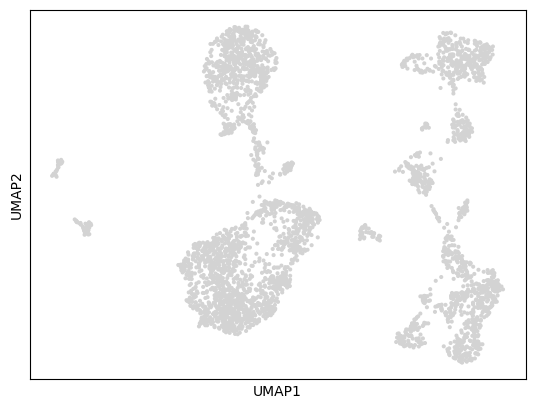

In [77]:
# ============================================================
# 17. UMAP Visualisation
# ============================================================

# UMAP (Uniform Manifold Approximation and Projection)
# projects the high-dimensional cell embeddings into
# a 2D space for visualisation.
#
# The visualisation is constructed using the
# previously generated neighbour graph.
#
# Cells with similar biological profiles are placed
# close together, while biologically distinct cells
# appear further apart.
#
# UMAP is commonly used in single-cell analysis to:
# - identify cell populations
# - inspect clustering structure
# - evaluate preprocessing quality
# - visualise learned embeddings

sc.tl.umap(adata)

# Plot the UMAP embedding.

sc.pl.umap(adata)